# Data Cleaning Informe ECF 2021

## Librerias

In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

## Carga del fichero csv

In [3]:
df = pd.read_csv(
    r"..\Data\Silver_ECF_090226.csv",
    sep=","
)
df.shape

(7554, 25)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7554 entries, 0 to 7553
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   cat_educacion       7554 non-null   object
 1   estado_laboral      7554 non-null   object
 2   familia             7554 non-null   object
 3   riq_inmob           7554 non-null   object
 4   ahorro              7554 non-null   int64 
 5   deuda               7554 non-null   int64 
 6   adq_ahorro2         7554 non-null   int64 
 7   adq_deuda2          7554 non-null   int64 
 8   adq_otro            7554 non-null   int64 
 9   ahorra_12m          7554 non-null   int64 
 10  consumo_ahorros     7554 non-null   int64 
 11  cred_inf            7554 non-null   int64 
 12  cred_form           7554 non-null   int64 
 13  cred_add            7554 non-null   int64 
 14  impago              7554 non-null   int64 
 15  ayudas              7554 non-null   int64 
 16  rechazo             7554

In [5]:
df.head()

,cat_educacion,estado_laboral,familia,riq_inmob,ahorro,deuda,adq_ahorro2,adq_deuda2,adq_otro,ahorra_12m,...,ayudas,rechazo,semirechazo,nopiden,age,ID,year,inflacion_ok,interes_comp_ok,diversificacion_ok
0,Universidad,Asalariado,Vive con pareja,Solo residencia principal,0,1,0,1,1,1,...,0,0,0,0,40,1,2022,0,0,-1
1,Universidad,Asalariado,Otros adultos,Residencia principal y otras,0,1,0,0,0,0,...,0,0,0,1,54,2,2022,1,-1,-1
2,Educación Secundaria,Asalariado,Vive solo,Residencia principal y otras,1,0,1,0,1,1,...,0,0,0,0,54,3,2022,1,1,1
3,Educación Secundaria,Asalariado,Vive con pareja,Solo residencia principal,1,1,0,0,0,1,...,0,0,0,0,48,4,2022,0,0,-1
4,Educación Primaria,Asalariado,Otros adultos,Solo residencia principal,0,1,0,1,1,0,...,0,0,0,0,49,5,2022,1,-1,-1


In [7]:
df.columns.tolist()


['cat_educacion',
 'estado_laboral',
 'familia',
 'riq_inmob',
 'ahorro',
 'deuda',
 'adq_ahorro2',
 'adq_deuda2',
 'adq_otro',
 'ahorra_12m',
 'consumo_ahorros',
 'cred_inf',
 'cred_form',
 'cred_add',
 'impago',
 'ayudas',
 'rechazo',
 'semirechazo',
 'nopiden',
 'age',
 'ID',
 'year',
 'inflacion_ok',
 'interes_comp_ok',
 'diversificacion_ok']

#### 1.3. Identificar indicadores de vulnerabilidad
Uso:
- Uso de préstamos para cubrir gastos
- Morosidad
- Denegaciones de préstamos

In [46]:
# VULNERABILIDAD 

# Uso de préstamos para cubrir gastos
df["prestamo_gastos"] = (
    (df["cred_inf"] == 1) |
    (df["cred_form"] == 1) |
    (df["cred_add"] == 1)
).astype(int)

# Morosidad
df["morosidad"] = (df["impago"] == 1).astype(int)

# Denegación de crédito
df["denegacion_credito"] = (
    (df["rechazo"] == 1) |
    (df["semirechazo"] == 1)
).astype(int)

# Uso de ahorros para cubrir gastos
df["uso_ahorros"] = (df["consumo_ahorros"] == 1).astype(int)


# VULNERABILIDAD FINAL (1 si cumple al menos una condición)

df["vulnerabilidad"] = (
    (df["prestamo_gastos"] == 1) |
    (df["morosidad"] == 1) |
    (df["denegacion_credito"] == 1) |
    (df["uso_ahorros"] == 1)
).astype(int)


# CHECK

df[[
    "prestamo_gastos",
    "morosidad",
    "denegacion_credito",
    "uso_ahorros",
    "vulnerabilidad"
]].mean().round(3)


prestamo_gastos       0.101
morosidad             0.027
denegacion_credito    0.044
uso_ahorros           0.132
vulnerabilidad        0.235
dtype: float64

In [47]:
resumen_vuln = pd.DataFrame({
    "conteo": df["vulnerabilidad"].value_counts().sort_index(),
    "proporcion": df["vulnerabilidad"].value_counts(normalize=True).sort_index()
})

resumen_vuln.round(3)


,conteo,proporcion
vulnerabilidad,,
0,5780,0.765
1,1774,0.235


##### 1.3.a. vulnerabilidad x education

In [ ]:
vuln_edu = pd.crosstab(
    df["cat_educacion"],
    df["vulnerabilidad"],
    normalize="index"
).round(2)

vuln_edu



vulnerabilidad,0,1
cat_educacion,,
Educación Primaria,0.69,0.31
Educación Secundaria,0.75,0.25
Universidad,0.84,0.16


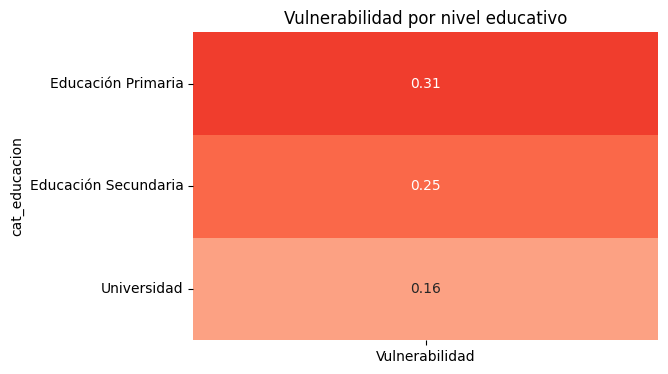

In [50]:
tabla_edu = pd.crosstab(
    df["cat_educacion"],
    df["vulnerabilidad"],
    normalize="index"
)[1]

tabla_edu = tabla_edu.to_frame(name="Vulnerabilidad")

plt.figure(figsize=(6,4))
sns.heatmap(
    tabla_edu,
    annot=True,
    cmap="Reds",
    vmin=0,
    vmax=0.5,
    cbar=False
)

plt.title("Vulnerabilidad por nivel educativo")
plt.show()



##### 1.3.b. vulnerabilidad x estado_laboral

In [51]:
pd.crosstab(
    df["estado_laboral"],
    df["vulnerabilidad"],
    normalize="index"
).round(2)



vulnerabilidad,0,1
estado_laboral,,
Asalariado,0.78,0.22
Autónomo,0.77,0.23
Desempleado,0.61,0.39
Jubilado,0.82,0.18
Otros inactivos,0.75,0.25


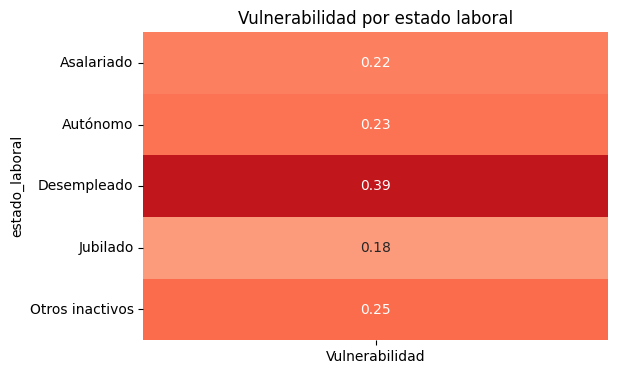

In [52]:
tabla_lab = pd.crosstab(
    df["estado_laboral"],
    df["vulnerabilidad"],
    normalize="index"
)[1]

tabla_lab = tabla_lab.to_frame(name="Vulnerabilidad")

plt.figure(figsize=(6,4))
sns.heatmap(
    tabla_lab,
    annot=True,
    cmap="Reds",
    vmin=0,
    vmax=0.5,
    cbar=False
)

plt.title("Vulnerabilidad por estado laboral")
plt.show()


##### 1.3.c. vulnerabilidad x familia


In [53]:
pd.crosstab(
    df["familia"],
    df["vulnerabilidad"],
    normalize="index"
).round(2)



vulnerabilidad,0,1
familia,,
Otros adultos,0.77,0.23
Vive con pareja,0.77,0.23
Vive solo,0.74,0.26


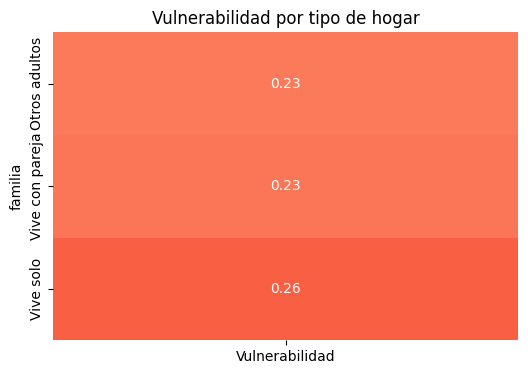

In [54]:
tabla_hog = pd.crosstab(
    df["familia"],
    df["vulnerabilidad"],
    normalize="index"
)[1]

tabla_hog = tabla_hog.to_frame(name="Vulnerabilidad")

plt.figure(figsize=(6,4))
sns.heatmap(
    tabla_hog,
    annot=True,
    cmap="Reds",
    vmin=0,
    vmax=0.5,
    cbar=False
)

plt.title("Vulnerabilidad por tipo de hogar")
plt.show()


##### 1.3.a. vulnerabilidad x age

In [55]:
vuln_age = pd.crosstab(
    df["age"],
    df["vulnerabilidad"],
    normalize="index"
).round(2)

vuln_age


vulnerabilidad,0,1
age,,
18,0.73,0.27
19,0.81,0.19
20,0.83,0.17
21,0.82,0.18
22,0.79,0.21
...,...,...
76,0.78,0.22
77,0.86,0.14
78,0.92,0.08


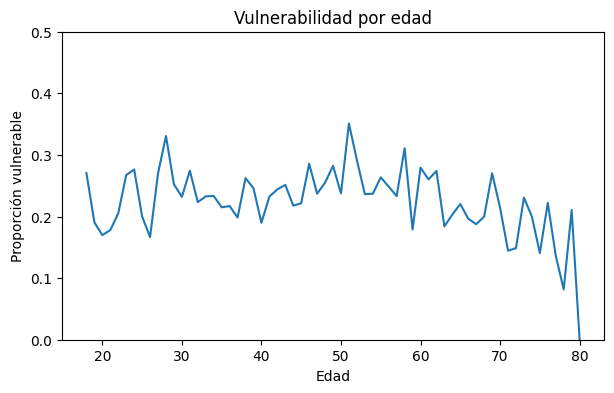

In [56]:
tabla_age = pd.crosstab(
    df["age"],
    df["vulnerabilidad"],
    normalize="index"
)[1]

plt.figure(figsize=(7,4))
plt.plot(tabla_age.index, tabla_age.values)

plt.title("Vulnerabilidad por edad")
plt.xlabel("Edad")
plt.ylabel("Proporción vulnerable")
plt.ylim(0, 0.5)

plt.show()


## hacer Vulenrabilidad por alfabetizacion y otros